# Lab 3: Contextual Bandit-Based News Article Recommendation

**`Course`:** Reinforcement Learning Fundamentals  
**`Student Name`:**  Lipi Singhal
**`Roll Number`:**  U20230097
**`GitHub Branch`:** lipi_U20230097  

# Imports and Setup

In [183]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from rlcmab_sampler import sampler


# Load Datasets

In [184]:
# Load datasets
news_df = pd.read_csv("data/news_articles.csv")
train_users = pd.read_csv("data/train_users.csv")
test_users = pd.read_csv("data/test_users.csv")

print("News Articles Dataset Shape:", news_df.shape)
print("Train Users Dataset Shape:", train_users.shape)
print("Test Users Dataset Shape:", test_users.shape)
print("\n\nNews Categories:")
print(news_df['category'].value_counts())
print("\nTrain User Categories:")
print(train_users['label'].value_counts())


News Articles Dataset Shape: (209527, 6)
Train Users Dataset Shape: (2000, 33)
Test Users Dataset Shape: (2000, 32)


News Categories:
category
POLITICS          35602
WELLNESS          17945
ENTERTAINMENT     17362
TRAVEL             9900
STYLE & BEAUTY     9814
PARENTING          8791
HEALTHY LIVING     6694
QUEER VOICES       6347
FOOD & DRINK       6340
BUSINESS           5992
COMEDY             5400
SPORTS             5077
BLACK VOICES       4583
HOME & LIVING      4320
PARENTS            3955
THE WORLDPOST      3664
WEDDINGS           3653
WOMEN              3572
CRIME              3562
IMPACT             3484
DIVORCE            3426
WORLD NEWS         3299
MEDIA              2944
WEIRD NEWS         2777
GREEN              2622
WORLDPOST          2579
RELIGION           2577
STYLE              2254
SCIENCE            2206
TECH               2104
TASTE              2096
MONEY              1756
ARTS               1509
ENVIRONMENT        1444
FIFTY              1401
GOOD NEWS       

## Data Preprocessing

In this section:
- Handle missing values
- Encode categorical features
- Prepare data for user classification

In [185]:
# Checking for missing values
print("Missing values in news_df:")
print(news_df.isnull().sum())
print("\nMissing values in train_users:")
print(train_users.isnull().sum())
print("\nMissing values in test_users:")
print(test_users.isnull().sum())

# Clean news articles - drop rows with missing category
news_df_clean = news_df.dropna(subset=['category', 'headline']).reset_index(drop=True)

Missing values in news_df:
link                     0
headline                 6
category                 0
short_description    19712
authors              37418
date                     0
dtype: int64

Missing values in train_users:
user_id                          0
age                            698
income                           0
clicks                           0
purchase_amount                  0
session_duration                 0
content_variety                  0
engagement_score                 0
num_transactions                 0
avg_monthly_spend                0
avg_cart_value                   0
browsing_depth                   0
revisit_rate                     0
scroll_activity                  0
time_on_site                     0
interaction_count                0
preferred_price_range            0
discount_usage_rate              0
wishlist_size                    0
product_views                    0
repeat_purchase_gap (days)       0
churn_risk_score               

In [186]:
# Category mapping - 4 categories: Entertainment, Education, Tech, Crime
category_mapping = {
    'ENTERTAINMENT': 'Entertainment',
    'COMEDY': 'Entertainment',
    'PARENTING': 'Entertainment',
    'SPORTS': 'Entertainment',
    'CULTURE & ARTS': 'Entertainment',
    'MEDIA': 'Entertainment',
    'WEIRD NEWS': 'Entertainment',
    'STYLE': 'Entertainment',
    'STYLE & BEAUTY': 'Entertainment',
    'TASTE': 'Entertainment',
    'TRAVEL': 'Entertainment',
    'WEDDINGS': 'Entertainment',
    'ARTS': 'Entertainment',
    'ARTS & CULTURE': 'Entertainment',
    'FOOD & DRINK': 'Entertainment',
    'GOOD NEWS': 'Entertainment',
    'GREEN': 'Entertainment',
    'HOME & LIVING': 'Entertainment',
    
    'EDUCATION': 'Education',
    'COLLEGE': 'Education',
    'PARENTS': 'Education',
    
    'TECH': 'Tech',
    'SCIENCE': 'Tech',
    'BUSINESS': 'Tech',
    
    'CRIME': 'Crime',
    'BLACK VOICES': 'Crime',
    'POLITICS': 'Crime',
    'U.S. NEWS': 'Crime',
    'WORLD NEWS': 'Crime',
    'WORLDPOST': 'Crime',
    'ENVIRONMENT': 'Crime',
    'WELLNESS': 'Crime',
    'HEALTHY LIVING': 'Crime',
    'QUEER VOICES': 'Crime',
    'WOMEN': 'Crime',
    'LATINO VOICES': 'Crime',
    'RELIGION': 'Crime',
    'IMPACT': 'Crime',
    'DIVORCE': 'Crime',
    'FIFTY': 'Crime',
    'MONEY': 'Crime'
}

news_df_clean['category'] = news_df_clean['category'].map(
    lambda x: category_mapping.get(x, 'Entertainment')
)

# Keep only the 4 categories from assignment
valid_categories = ['Entertainment', 'Education', 'Tech', 'Crime']
news_df_clean = news_df_clean[news_df_clean['category'].isin(valid_categories)]

print(f"\nCleaned News Articles: {news_df_clean.shape}")
print("\nNews Category Distribution:")
print(news_df_clean['category'].value_counts())


Cleaned News Articles: (209521, 6)

News Category Distribution:
category
Crime            100774
Entertainment     92333
Tech              10301
Education          6113
Name: count, dtype: int64


In [187]:
# Filling missing age with median
train_users_clean = train_users.copy()
test_users_clean = test_users.copy()

age_median = train_users_clean['age'].median()
train_users_clean['age'].fillna(age_median, inplace=True)
test_users_clean['age'].fillna(age_median, inplace=True)

/var/folders/jx/8n7khtqd3kj995b8dsj6j8bw0000gn/T/ipykernel_93933/1834028968.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_users_clean['age'].fillna(age_median, inplace=True)
/var/folders/jx/8n7khtqd3kj995b8dsj6j8bw0000gn/T/ipykernel_93933/1834028968.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting va

In [188]:
# Encoding categorical features
# Region code encoding - FIT ON BOTH TRAIN AND TEST to avoid unseen labels
all_region_codes = pd.concat([train_users_clean['region_code'], 
                               test_users_clean['region_code']]).unique()
le_region = LabelEncoder()
le_region.fit(all_region_codes)

train_users_clean['region_code_encoded'] = le_region.transform(train_users_clean['region_code'])
test_users_clean['region_code_encoded'] = le_region.transform(test_users_clean['region_code'])

# Subscriber encoding (Boolean to int)
train_users_clean['subscriber_encoded'] = train_users_clean['subscriber'].astype(int)
test_users_clean['subscriber_encoded'] = test_users_clean['subscriber'].astype(int)

# Encode user labels for classification
le_user = LabelEncoder()
train_users_clean['label_encoded'] = le_user.fit_transform(train_users_clean['label'])

print(f"\nCleaned Train Users: {train_users_clean.shape}")
print(f"Cleaned Test Users: {test_users_clean.shape}")
print("\nUser Label Mapping:")
for i, label in enumerate(le_user.classes_):
    print(f"{i}: {label}")


Cleaned Train Users: (2000, 36)
Cleaned Test Users: (2000, 34)

User Label Mapping:
0: user_1
1: user_2
2: user_3


## User Classification

Train a classifier to predict the user category (`User1`, `User2`, `User3`),
which serves as the **context** for the contextual bandit.


In [189]:
## Selecting features and target for classification
exclude_cols = ['user_id', 'region_code', 'subscriber', 'label', 'browser_version']

feature_cols = [
    col for col in train_users_clean.columns
    if col not in exclude_cols
    and col not in ['label_encoded', 'region_code_encoded', 'subscriber_encoded']
]

feature_cols.extend(['region_code_encoded', 'subscriber_encoded'])

TRAIN_FEATURES = feature_cols.copy()


label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(train_users_clean['label'])


X_train, X_val, y_train, y_val = train_test_split(
    train_users_clean[TRAIN_FEATURES],
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)


print(f"\nTraining set size: {X_train.shape}")
print(f"Validation set size: {X_val.shape}")


Training set size: (1600, 30)
Validation set size: (400, 30)


In [190]:
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=TRAIN_FEATURES,
    index=X_train.index
)

X_val_scaled = pd.DataFrame(
    scaler.transform(X_val),
    columns=TRAIN_FEATURES,
    index=X_val.index
)

In [191]:
classifiers = {
    'Decision Tree': DecisionTreeClassifier(
        random_state=42,
        max_depth=10
    ),
    'Logistic Regression': LogisticRegression(
        random_state=42,
        max_iter=5000,
        solver='lbfgs'
    ),
    'Random Forest': RandomForestClassifier(
        random_state=42,
        n_estimators=100,
        n_jobs=-1
    )
}

results = {}

TRAIN_FEATURES = X_train_scaled.columns.tolist()

print("=" * 80)
print("CLASSIFIER TRAINING AND EVALUATION")
print("=" * 80)
print(f"\nTraining on {X_train_scaled.shape[0]} samples with {X_train_scaled.shape[1]} features")


for name, clf in classifiers.items():
    print(f"\nTraining {name}...")
    
    clf.fit(X_train_scaled, y_train)
    
    # Verify feature count
    if hasattr(clf, 'n_features_in_'):
        print(f"  Model expects {clf.n_features_in_} features")
    
    y_pred = clf.predict(X_val_scaled)
    accuracy = accuracy_score(y_val, y_pred)
    
    results[name] = {
        'model': clf,
        'accuracy': accuracy,
        'predictions': y_pred
    }
    
    print(f"  Accuracy: {accuracy:.4f}")

# Select best classifier
best_classifier_name = max(results, key=lambda x: results[x]['accuracy'])
best_classifier = results[best_classifier_name]['model']
best_accuracy = results[best_classifier_name]['accuracy']

print(f"\n{'=' * 80}")
print(f"BEST CLASSIFIER: {best_classifier_name} (Accuracy: {best_accuracy:.4f})")
print(f"Best model expects {best_classifier.n_features_in_} features")
print(f"{'=' * 80}")

BEST_MODEL_META = {
    'classifier': best_classifier,
    'scaler': scaler,
    'train_features': TRAIN_FEATURES,
    'label_encoder': label_encoder
}

print("✓ Best model metadata stored for recommendation system")

CLASSIFIER TRAINING AND EVALUATION

Training on 1600 samples with 30 features

Training Decision Tree...
  Model expects 30 features
  Accuracy: 0.8600

Training Logistic Regression...
  Model expects 30 features
  Accuracy: 0.8175

Training Random Forest...
  Model expects 30 features
  Accuracy: 0.8975

BEST CLASSIFIER: Random Forest (Accuracy: 0.8975)
Best model expects 30 features
✓ Best model metadata stored for recommendation system


In [192]:
print(f"Classification Report for Best Classifier: {best_classifier_name}\n")
print(classification_report(y_val, results[best_classifier_name]['predictions'], target_names=le_user.classes_))

Classification Report for Best Classifier: Random Forest

              precision    recall  f1-score   support

      user_1       0.89      0.86      0.87       142
      user_2       0.98      0.87      0.92       142
      user_3       0.83      0.97      0.90       116

    accuracy                           0.90       400
   macro avg       0.90      0.90      0.90       400
weighted avg       0.90      0.90      0.90       400



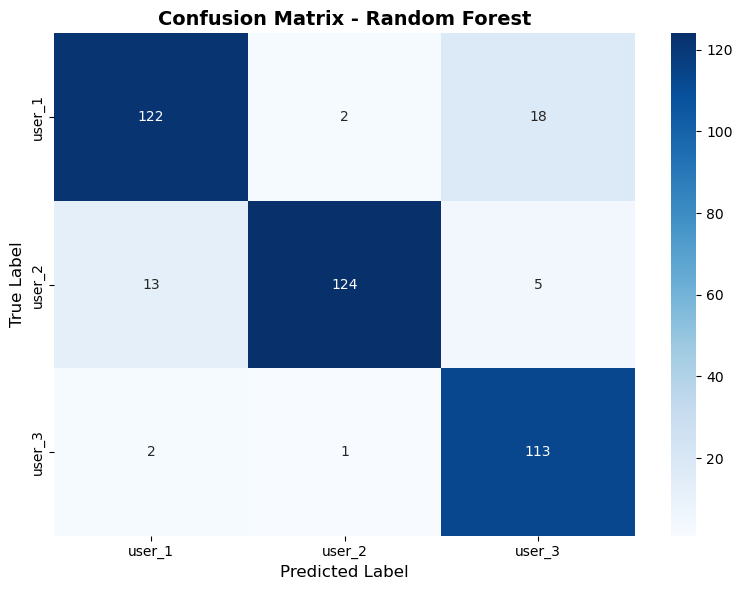

In [193]:
cm = confusion_matrix(y_val, results[best_classifier_name]['predictions'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title(f'Confusion Matrix - {best_classifier_name}', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

# `Contextual Bandit`

## Reward Sampler Initialization

The sampler is initialized using the student's roll number `i`.
Rewards are obtained using `sampler.sample(j)`.


In [194]:
# Roll number - U20230097
ROLL_NO = 97
reward_sampler = sampler(ROLL_NO)

## Arm Mapping

| Arm Index (j) | News Category | User Context |
|--------------|---------------|--------------|
| 0–3          | Entertainment, Education, Tech, Crime | User1 |
| 4–7          | Entertainment, Education, Tech, Crime | User2 |
| 8–11         | Entertainment, Education, Tech, Crime | User3 |

In [195]:
def get_arm_index(user_context_idx, category):
    category_to_offset = {
        'Entertainment': 0,
        'Education': 1,
        'Tech': 2,
        'Crime': 3
    }
    base_arm = user_context_idx * 4
    return base_arm + category_to_offset[category]

categories = ['Entertainment', 'Education', 'Tech', 'Crime']
user_contexts = ['user_1', 'user_2', 'user_3']

print("Testing the sampler:")
for i in range(12):
    reward = reward_sampler.sample(i)

    user_context_idx = i // 4
    category_idx = i % 4
    
    user_context = user_contexts[user_context_idx]
    category = categories[category_idx]

    print(f"Arm {i}: {category:15s} + {user_context:6s} --> reward = {reward:.4f}")

Testing the sampler:
Arm 0: Entertainment   + user_1 --> reward = 1.8607
Arm 1: Education       + user_1 --> reward = 0.2435
Arm 2: Tech            + user_1 --> reward = -7.0620
Arm 3: Crime           + user_1 --> reward = 4.8637
Arm 4: Entertainment   + user_2 --> reward = -3.2171
Arm 5: Education       + user_2 --> reward = -3.0927
Arm 6: Tech            + user_2 --> reward = -7.4559
Arm 7: Crime           + user_2 --> reward = 3.3590
Arm 8: Entertainment   + user_3 --> reward = -1.5942
Arm 9: Education       + user_3 --> reward = 0.5290
Arm 10: Tech            + user_3 --> reward = 4.5267
Arm 11: Crime           + user_3 --> reward = 4.7775


## Epsilon-Greedy Strategy

This section implements the epsilon-greedy contextual bandit algorithm.


In [196]:
class EpsilonGreedy:
    def __init__(self, n_arms_per_context, epsilon, reward_sampler):
        self.n_arms_per_context = n_arms_per_context  
        self.epsilon = epsilon
        self.reward_sampler = reward_sampler
        self.categories = ['Entertainment', 'Education', 'Tech', 'Crime']
        self.Q = [{cat: 0.0 for cat in self.categories} for _ in range(3)]    # Average rewards
        self.N = [{cat: 0 for cat in self.categories} for _ in range(3)]   # Counts

    # function to select arm based on epsilon-greedy strategy    
    def select_arm(self, context_idx):             
        if np.random.random() < self.epsilon:
            category = np.random.choice(self.categories)        # Explore: random category
        else:
            category = max(self.categories, key=lambda c: self.Q[context_idx][c])            # Exploit: best category for this context
        return category
    
    # function to update Q-values based on observed reward
    def update(self, context_idx, category, reward):
        self.N[context_idx][category] += 1
        n = self.N[context_idx][category]
        old_q = self.Q[context_idx][category]
        self.Q[context_idx][category] = old_q + (reward - old_q) / n    # Incremental average

    # function to get reward from sampler based on context and category
    def get_reward(self, context_idx, category):
        arm_idx = get_arm_index(context_idx, category)
        return self.reward_sampler.sample(arm_idx)


In [197]:
# Testing
epsilon_values = [0.1, 0.2, 0.3]
T = 10000

epsilon_results = {}

for eps in epsilon_values:
    print(f"\nRunning Epsilon-Greedy with ε={eps}...")
    
    bandit = EpsilonGreedy(n_arms_per_context=4, epsilon=eps, reward_sampler=reward_sampler)
    
    rewards_by_context = {0: [], 1: [], 2: []}
    total_rewards = []
    
    for t in range(T):
        context_idx = int(np.random.choice([0, 1, 2]))        # Randomly sample a context (user type)
        
        category = bandit.select_arm(context_idx)      
        
        reward = bandit.get_reward(context_idx, category) 
    
        bandit.update(context_idx, category, reward)
        
        rewards_by_context[context_idx].append(reward)
        total_rewards.append(reward)
    
    epsilon_results[eps] = {
        'bandit': bandit,
        'rewards_by_context': rewards_by_context,
        'total_rewards': total_rewards,
        'Q': bandit.Q,
        'N': bandit.N
    }
    
    print(f"Average reward: {np.mean(total_rewards):.4f}")
    print(f"Final Q-values:")
    for ctx_idx in range(3):
        print(f"  Context {ctx_idx} (user_{ctx_idx+1}): {bandit.Q[ctx_idx]}")


Running Epsilon-Greedy with ε=0.1...
Average reward: 3.7135
Final Q-values:
  Context 0 (user_1): {'Entertainment': 3.0784673934643187, 'Education': 1.236976522288156, 'Tech': -6.411100008767746, 'Crime': 3.318887164430134}
  Context 1 (user_2): {'Entertainment': -2.553785949617153, 'Education': -2.557822488576014, 'Tech': -8.656922159474595, 'Crime': 3.9827772045448024}
  Context 2 (user_3): {'Entertainment': -2.2337693591773364, 'Education': 0.6609862818470047, 'Tech': 5.2466520465572675, 'Crime': 4.302198074786948}

Running Epsilon-Greedy with ε=0.2...
Average reward: 3.3591
Final Q-values:
  Context 0 (user_1): {'Entertainment': 2.901465237621727, 'Education': 1.3704194253269348, 'Tech': -6.455550718128844, 'Crime': 3.363791962374867}
  Context 1 (user_2): {'Entertainment': -2.4251394479773065, 'Education': -2.69652136886509, 'Tech': -8.522492675426266, 'Crime': 4.005492539524361}
  Context 2 (user_3): {'Entertainment': -2.5214378574885075, 'Education': 0.5202620144944812, 'Tech':

## Upper Confidence Bound (UCB)

This section implements the UCB strategy for contextual bandits.

In [198]:
class UCB:
    def __init__(self, n_arms_per_context, c, reward_sampler):
        self.n_arms_per_context = n_arms_per_context
        self.c = c  # exploration parameter
        self.reward_sampler = reward_sampler
        self.categories = ['Entertainment', 'Education', 'Tech', 'Crime']
        
        self.Q = [{cat: 0.0 for cat in self.categories} for _ in range(3)]
        self.N = [{cat: 0 for cat in self.categories} for _ in range(3)]
        self.t = 0  # time steps
        
    # function to select arm based on UCB strategy
    def select_arm(self, context_idx):
        self.t += 1
        
        # if any arm hasn't been tried, try it
        for cat in self.categories:
            if self.N[context_idx][cat] == 0:
                return cat
        
        ucb_values = {}
        for cat in self.categories:
            exploitation = self.Q[context_idx][cat]
            exploration = self.c * np.sqrt(np.log(self.t) / self.N[context_idx][cat])
            ucb_values[cat] = exploitation + exploration
        
        # Select arm with highest UCB
        return max(ucb_values, key=ucb_values.get)
    
    # function to update Q-values based on observed reward
    def update(self, context_idx, category, reward):
        self.N[context_idx][category] += 1
        n = self.N[context_idx][category]
        old_q = self.Q[context_idx][category]
        self.Q[context_idx][category] = old_q + (reward - old_q) / n
    
    # function to get reward from sampler based on context and category
    def get_reward(self, context_idx, category):
        arm_idx = get_arm_index(context_idx, category)
        return self.reward_sampler.sample(arm_idx)

In [199]:
# Testing
c_values = [0.5, 1.0, 2.0]
T = 10000

ucb_results = {}

for c in c_values:
    print(f"\nRunning UCB with C={c}...")
    
    bandit = UCB(n_arms_per_context=4, c=c, reward_sampler=reward_sampler)
    
    rewards_by_context = {0: [], 1: [], 2: []}
    total_rewards = []
    
    for t in range(T):
        context_idx = int(np.random.choice([0, 1, 2]))
        category = bandit.select_arm(context_idx)
        reward = bandit.get_reward(context_idx, category)
        bandit.update(context_idx, category, reward)
        
        rewards_by_context[context_idx].append(reward)
        total_rewards.append(reward)
    
    ucb_results[c] = {
        'bandit': bandit,
        'rewards_by_context': rewards_by_context,
        'total_rewards': total_rewards,
        'Q': bandit.Q,
        'N': bandit.N
    }
    
    print(f"Average reward: {np.mean(total_rewards):.4f}")
    print(f"Final Q-values:")
    for ctx_idx in range(3):
        print(f"  Context {ctx_idx} (user_{ctx_idx+1}): {bandit.Q[ctx_idx]}")


Running UCB with C=0.5...
Average reward: 4.2041
Final Q-values:
  Context 0 (user_1): {'Entertainment': 3.089088691193003, 'Education': 1.5005950527346887, 'Tech': -7.810017903824712, 'Crime': 3.361014903207366}
  Context 1 (user_2): {'Entertainment': -2.4693668533939506, 'Education': -4.822694411864628, 'Tech': -9.241787218040235, 'Crime': 3.9804781757483467}
  Context 2 (user_3): {'Entertainment': -1.1878769641586235, 'Education': 2.5041435390468467, 'Tech': 5.289809348649967, 'Crime': 3.724314723229946}

Running UCB with C=1.0...
Average reward: 4.2126
Final Q-values:
  Context 0 (user_1): {'Entertainment': 1.9490546878246302, 'Education': 1.4542291169059227, 'Tech': -6.947809841185066, 'Crime': 3.325872047275466}
  Context 1 (user_2): {'Entertainment': 0.5426671664692218, 'Education': -5.475127283253581, 'Tech': -8.388798022581138, 'Crime': 4.00369465339606}
  Context 2 (user_3): {'Entertainment': -1.9507576301694278, 'Education': -0.08031873041898563, 'Tech': 5.322780590285669, 

## SoftMax Strategy

This section implements the SoftMax strategy with temperature $ \tau = 1$.


In [200]:
class SoftMax:
    def __init__(self, n_arms_per_context, tau, reward_sampler):
        self.n_arms_per_context = n_arms_per_context
        self.tau = tau  # temperature parameter
        self.reward_sampler = reward_sampler
        self.categories = ['Entertainment', 'Education', 'Tech', 'Crime']
        
        self.Q = [{cat: 0.0 for cat in self.categories} for _ in range(3)]
        self.N = [{cat: 0 for cat in self.categories} for _ in range(3)]
        
    # function to select arm based on SoftMax strategy    
    def select_arm(self, context_idx):
        q_values = np.array([self.Q[context_idx][cat] for cat in self.categories])
        exp_values = np.exp(q_values / self.tau)
        probabilities = exp_values / np.sum(exp_values)
        
        category_idx = np.random.choice(len(self.categories), p=probabilities)
        return self.categories[category_idx]
    
    # function to update Q-values based on observed reward
    def update(self, context_idx, category, reward):
        self.N[context_idx][category] += 1
        n = self.N[context_idx][category]
        old_q = self.Q[context_idx][category]
        self.Q[context_idx][category] = old_q + (reward - old_q) / n
    
    # function to get reward from sampler based on context and category
    def get_reward(self, context_idx, category):
        arm_idx = get_arm_index(context_idx, category)
        return self.reward_sampler.sample(arm_idx)

In [201]:
# Testing with tau=1
tau = 1.0
T = 10000

print(f"Running SoftMax with τ={tau}...")

softmax_bandit = SoftMax(n_arms_per_context=4, tau=tau, reward_sampler=reward_sampler)

softmax_rewards_by_context = {0: [], 1: [], 2: []}
softmax_total_rewards = []

for t in range(T):
    context_idx = int(np.random.choice([0, 1, 2]))
    category = softmax_bandit.select_arm(context_idx)
    reward = softmax_bandit.get_reward(context_idx, category)
    softmax_bandit.update(context_idx, category, reward)
    
    softmax_rewards_by_context[context_idx].append(reward)
    softmax_total_rewards.append(reward)

print(f"Average reward: {np.mean(softmax_total_rewards):.4f}")
print(f"Final Q-values:")
for ctx_idx in range(3):
    print(f"  Context {ctx_idx} (user_{ctx_idx+1}): {softmax_bandit.Q[ctx_idx]}")

softmax_results = {
    'bandit': softmax_bandit,
    'rewards_by_context': softmax_rewards_by_context,
    'total_rewards': softmax_total_rewards,
    'Q': softmax_bandit.Q,
    'N': softmax_bandit.N
}

Running SoftMax with τ=1.0...
Average reward: 4.0070
Final Q-values:
  Context 0 (user_1): {'Entertainment': 3.041772886409828, 'Education': 1.1305623235541622, 'Tech': -5.079293062649625, 'Crime': 3.3552512728359454}
  Context 1 (user_2): {'Entertainment': -2.026619058431536, 'Education': -2.8250794835336404, 'Tech': -10.22775669844321, 'Crime': 3.999865302606417}
  Context 2 (user_3): {'Entertainment': -2.90562517262417, 'Education': 0.7028086676144027, 'Tech': 5.243209729043145, 'Crime': 4.428315815324703}


## Reinforcement Learning Simulation

We simulate the bandit algorithms for $T = 10,000$ steps and record rewards.

P.S.: Change $T$ value as and if required.


In [202]:
# Already simulated with T = 10,000 after respective implementations of Epsilon-Greedy, UCB, and SoftMax. Results are printed above.

## Results and Analysis

This section presents:
- Average Reward vs Time
- Hyperparameter comparisons
- Observations and discussion


In [203]:
# Calculate cumulative average rewards
def calculate_cumulative_average(rewards_list):
    """Calculate cumulative average of rewards"""
    cumsum = np.cumsum(rewards_list)
    return cumsum / np.arange(1, len(rewards_list) + 1)

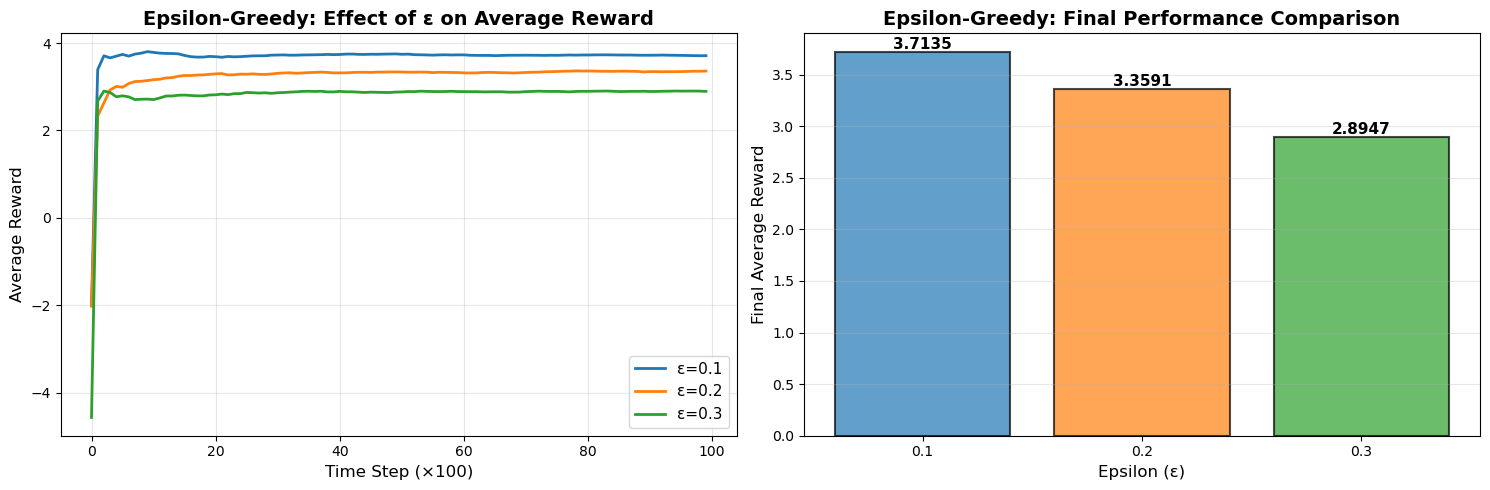


Epsilon-Greedy Performance Summary:
ε=0.1: Average Reward = 3.7135
ε=0.2: Average Reward = 3.3591
ε=0.3: Average Reward = 2.8947


In [204]:
# Comparing different Epsilon values:

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Average rewards across all contexts over time
ax = axes[0]
for eps in epsilon_values:
    total_rewards = epsilon_results[eps]['total_rewards']
    cum_avg = calculate_cumulative_average(total_rewards)
    # Plot every 100th point for clarity
    ax.plot(cum_avg[::100], label=f'ε={eps}', linewidth=2)

ax.set_xlabel('Time Step (×100)', fontsize=12)
ax.set_ylabel('Average Reward', fontsize=12)
ax.set_title('Epsilon-Greedy: Effect of ε on Average Reward', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Plot 2: Final average rewards
ax = axes[1]
final_avg_rewards = [np.mean(epsilon_results[eps]['total_rewards']) for eps in epsilon_values]
bars = ax.bar([str(eps) for eps in epsilon_values], final_avg_rewards, 
              color=['#1f77b4', '#ff7f0e', '#2ca02c'], alpha=0.7, edgecolor='black', linewidth=1.5)
ax.set_xlabel('Epsilon (ε)', fontsize=12)
ax.set_ylabel('Final Average Reward', fontsize=12)
ax.set_title('Epsilon-Greedy: Final Performance Comparison', fontsize=14, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)

# Add value labels on bars
for bar, val in zip(bars, final_avg_rewards):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary
print("\nEpsilon-Greedy Performance Summary:")
print("="*60)
for eps in epsilon_values:
    avg_reward = np.mean(epsilon_results[eps]['total_rewards'])
    print(f"ε={eps}: Average Reward = {avg_reward:.4f}")

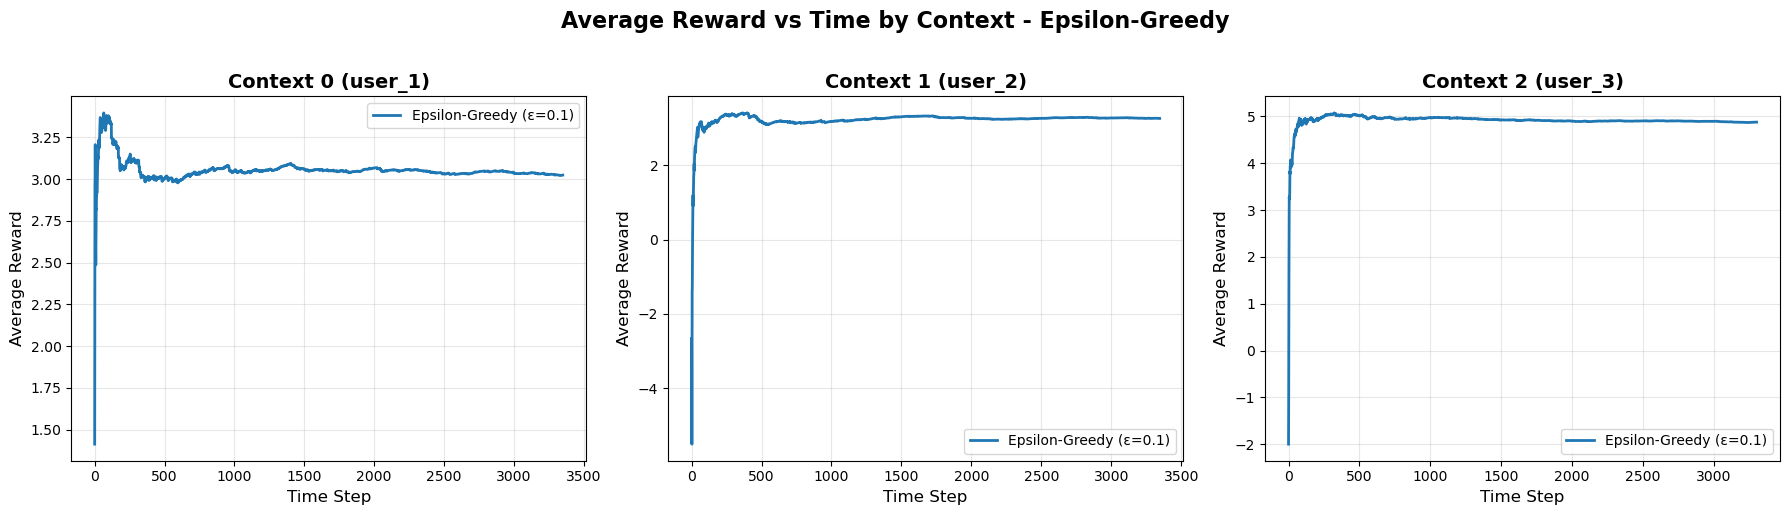

In [205]:
# Epsilon_greedy - Avg reward vs time for each context
best_eps = 0.1  # Chosen based on best performance

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ctx_idx in range(3):
    ax = axes[ctx_idx]
    
    # Get rewards for this context
    rewards = epsilon_results[best_eps]['rewards_by_context'][ctx_idx]
    
    if len(rewards) > 0:
        cum_avg = calculate_cumulative_average(rewards)
        ax.plot(cum_avg, label=f'Epsilon-Greedy (ε={best_eps})', linewidth=2, color='#1f77b4')
    
    ax.set_xlabel('Time Step', fontsize=12)
    ax.set_ylabel('Average Reward', fontsize=12)
    ax.set_title(f'Context {ctx_idx} (user_{ctx_idx+1})', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Average Reward vs Time by Context - Epsilon-Greedy', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

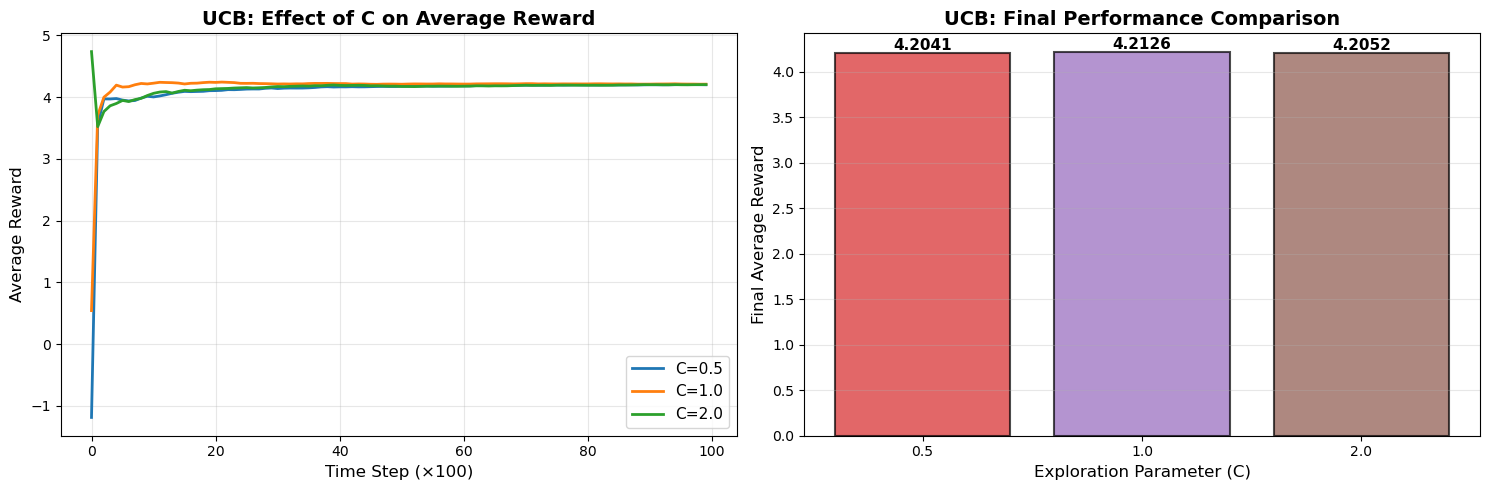


UCB Performance Summary:
C=0.5: Average Reward = 4.2041
C=1.0: Average Reward = 4.2126
C=2.0: Average Reward = 4.2052


In [206]:
# Compring different c values for UCB
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Average rewards across all contexts over time
ax = axes[0]
for c in c_values:
    total_rewards = ucb_results[c]['total_rewards']
    cum_avg = calculate_cumulative_average(total_rewards)
    ax.plot(cum_avg[::100], label=f'C={c}', linewidth=2)

ax.set_xlabel('Time Step (×100)', fontsize=12)
ax.set_ylabel('Average Reward', fontsize=12)
ax.set_title('UCB: Effect of C on Average Reward', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Plot 2: Final average rewards
ax = axes[1]
final_avg_rewards = [np.mean(ucb_results[c]['total_rewards']) for c in c_values]
bars = ax.bar([str(c) for c in c_values], final_avg_rewards, 
              color=['#d62728', '#9467bd', '#8c564b'], alpha=0.7, edgecolor='black', linewidth=1.5)
ax.set_xlabel('Exploration Parameter (C)', fontsize=12)
ax.set_ylabel('Final Average Reward', fontsize=12)
ax.set_title('UCB: Final Performance Comparison', fontsize=14, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)

# Add value labels on bars
for bar, val in zip(bars, final_avg_rewards):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary
print("\nUCB Performance Summary:")
print("="*60)
for c in c_values:
    avg_reward = np.mean(ucb_results[c]['total_rewards'])
    print(f"C={c}: Average Reward = {avg_reward:.4f}")

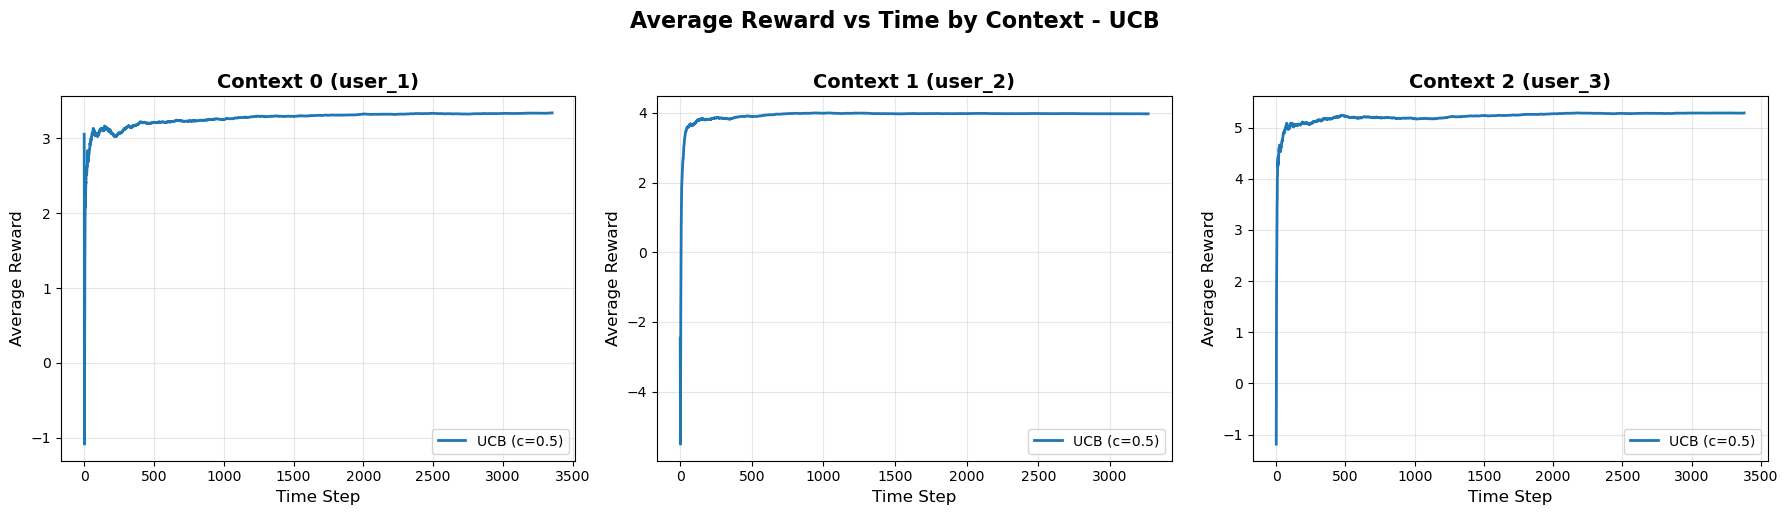

In [207]:
# UCB - Avg reward vs time for each context
best_c = 0.5  # Chosen based on best performance

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ctx_idx in range(3):
    ax = axes[ctx_idx]
    
    # Get rewards for this context
    rewards = ucb_results[best_c]['rewards_by_context'][ctx_idx]
    
    if len(rewards) > 0:
        cum_avg = calculate_cumulative_average(rewards)
        ax.plot(cum_avg, label=f'UCB (c={best_c})', linewidth=2, color='#1f77b4')
    
    ax.set_xlabel('Time Step', fontsize=12)
    ax.set_ylabel('Average Reward', fontsize=12)
    ax.set_title(f'Context {ctx_idx} (user_{ctx_idx+1})', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Average Reward vs Time by Context - UCB', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

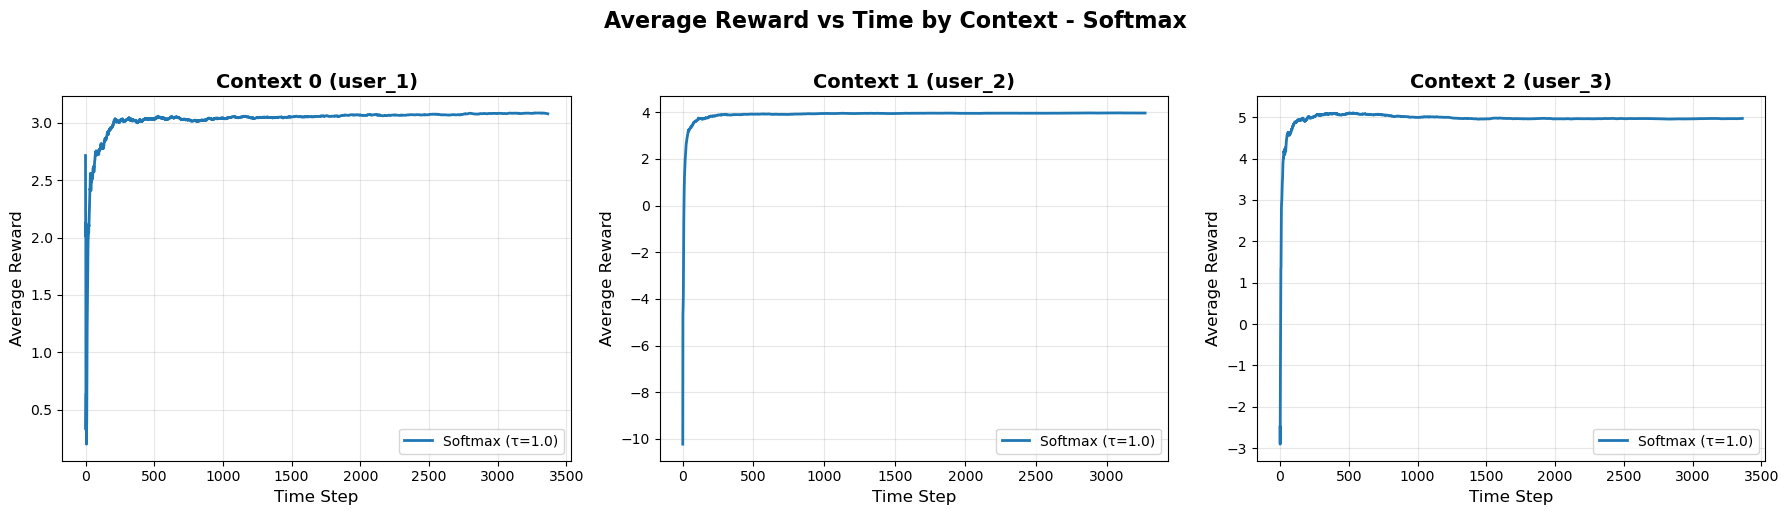

In [208]:
# Softmax - Avg reward vs time for each context

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ctx_idx in range(3):
    ax = axes[ctx_idx]
    
    # Get rewards for this context - FIX: Access directly from softmax_results
    rewards = softmax_results['rewards_by_context'][ctx_idx]
    
    if len(rewards) > 0:
        cum_avg = calculate_cumulative_average(rewards)
        ax.plot(cum_avg, label=f'Softmax (τ={tau})', linewidth=2, color='#1f77b4')
    
    ax.set_xlabel('Time Step', fontsize=12)
    ax.set_ylabel('Average Reward', fontsize=12)
    ax.set_title(f'Context {ctx_idx} (user_{ctx_idx+1})', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Average Reward vs Time by Context - Softmax', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Comparing all three Algorithms:

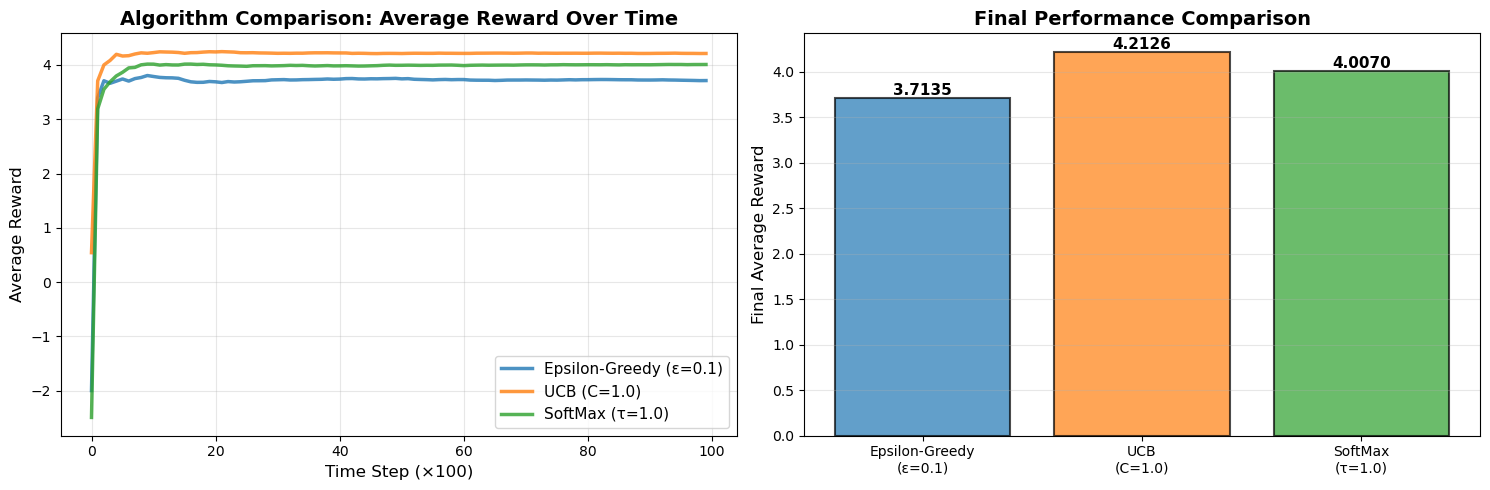


Final Algorithm Comparison:
Epsilon-Greedy (ε=0.1): 3.7135
UCB (C=1.0): 4.2126
SoftMax (τ=1.0): 4.0070


In [209]:

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Learning curves
ax = axes[0]

# Best epsilon-greedy
best_eps_result = epsilon_results[0.1]
cum_avg_eg = calculate_cumulative_average(best_eps_result['total_rewards'])
ax.plot(cum_avg_eg[::100], label='Epsilon-Greedy (ε=0.1)', linewidth=2.5, alpha=0.8)

# Best UCB
best_c_result = ucb_results[1.0]
cum_avg_ucb = calculate_cumulative_average(best_c_result['total_rewards'])
ax.plot(cum_avg_ucb[::100], label='UCB (C=1.0)', linewidth=2.5, alpha=0.8)

# SoftMax
cum_avg_sm = calculate_cumulative_average(softmax_results['total_rewards'])
ax.plot(cum_avg_sm[::100], label='SoftMax (τ=1.0)', linewidth=2.5, alpha=0.8)

ax.set_xlabel('Time Step (×100)', fontsize=12)
ax.set_ylabel('Average Reward', fontsize=12)
ax.set_title('Algorithm Comparison: Average Reward Over Time', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Plot 2: Final performance comparison
ax = axes[1]
algorithms = ['Epsilon-Greedy\n(ε=0.1)', 'UCB\n(C=1.0)', 'SoftMax\n(τ=1.0)']
avg_rewards = [
    np.mean(best_eps_result['total_rewards']),
    np.mean(best_c_result['total_rewards']),
    np.mean(softmax_results['total_rewards'])
]

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
bars = ax.bar(algorithms, avg_rewards, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Final Average Reward', fontsize=12)
ax.set_title('Final Performance Comparison', fontsize=14, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)

# Add value labels
for bar, val in zip(bars, avg_rewards):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("Final Algorithm Comparison:")
print("="*60)
print(f"Epsilon-Greedy (ε=0.1): {avg_rewards[0]:.4f}")
print(f"UCB (C=1.0): {avg_rewards[1]:.4f}")
print(f"SoftMax (τ=1.0): {avg_rewards[2]:.4f}")


In [210]:
## Identifying best algorithm

print("IDENTIFYING BEST ALGORITHM")

all_results = {}

# Add Epsilon-Greedy results
for eps in epsilon_values:
    avg_reward = np.mean(epsilon_results[eps]['total_rewards'])
    all_results[f'Epsilon-Greedy (ε={eps})'] = {
        'avg_reward': avg_reward,
        'bandit': epsilon_results[eps]['bandit'],
        'full_results': epsilon_results[eps]
    }

# Add UCB results
for c in c_values:
    avg_reward = np.mean(ucb_results[c]['total_rewards'])
    all_results[f'UCB (C={c})'] = {
        'avg_reward': avg_reward,
        'bandit': ucb_results[c]['bandit'],
        'full_results': ucb_results[c]
    }

# Add SoftMax results
avg_reward = np.mean(softmax_results['total_rewards'])
all_results['SoftMax (τ=1.0)'] = {
    'avg_reward': avg_reward,
    'bandit': softmax_results['bandit'],
    'full_results': softmax_results
}

# Find best configuration
best_config_name = max(all_results, key=lambda x: all_results[x]['avg_reward'])
best_config = all_results[best_config_name]

print(f"\nBEST ALGORITHM: {best_config_name}")
print(f"   Average Reward: {best_config['avg_reward']:.4f}")
print("\nRanking of all results:")
print("-"*80)

# Sort and display all results
sorted_results = sorted(all_results.items(), key=lambda x: x[1]['avg_reward'], reverse=True)
for rank, (name, data) in enumerate(sorted_results, 1):
    print(f"{rank}. {name:30s}: {data['avg_reward']:.4f}")

# Use the best bandit for recommendation engine
best_bandit = best_config['bandit']
best_full_results = best_config['full_results']

IDENTIFYING BEST ALGORITHM

BEST ALGORITHM: UCB (C=1.0)
   Average Reward: 4.2126

Ranking of all results:
--------------------------------------------------------------------------------
1. UCB (C=1.0)                   : 4.2126
2. UCB (C=2.0)                   : 4.2052
3. UCB (C=0.5)                   : 4.2041
4. SoftMax (τ=1.0)               : 4.0070
5. Epsilon-Greedy (ε=0.1)        : 3.7135
6. Epsilon-Greedy (ε=0.2)        : 3.3591
7. Epsilon-Greedy (ε=0.3)        : 2.8947


# Recommendation Engine

Implementation of end-to-end news recommendation system:
1. **Classify User** → Determine user category (user_1, user_2, user_3)
2. **Select Category** → Use best bandit policy to choose news category
3. **Recommend Article** → Sample article from selected category

In [219]:
class NewsRecommendationSystem:
    def __init__(self, classifier, bandit_model, news_df,
                 label_encoder, scaler, train_features):
        
        self.classifier = classifier
        self.bandit = bandit_model
        self.news_df = news_df
        self.label_encoder = label_encoder
        self.scaler = scaler
        self.train_features = train_features
        
    def recommend(self, user_features):

        # ================================
        # Step 1: Predict user context
        # ================================
        X_user = pd.DataFrame(
            self.scaler.transform(
                user_features[self.train_features].to_frame().T
            ),
            columns=self.train_features
        )

        context_idx = self.classifier.predict(X_user)[0]
        context_label = self.label_encoder.inverse_transform([context_idx])[0]
        
        # ================================
        # Step 2: UCB selects CATEGORY
        # ================================
        category = self.bandit.select_arm(context_idx)
        
        # ================================
        # Step 3: Sample article
        # ================================
        category_articles = self.news_df[self.news_df['category'] == category]
        recommended_article = (
            category_articles.sample(1).iloc[0]
            if len(category_articles) > 0 else None
        )
        
        return {
            'user_context': context_label,
            'recommended_category': category,
            'article': recommended_article
        }


In [220]:
print("Classifier expects:", best_classifier.n_features_in_)
print("Provided features:", len(feature_cols))
print("Extra columns:", set(feature_cols) - set(best_classifier.feature_names_in_))


Classifier expects: 30
Provided features: 30
Extra columns: set()


In [221]:
recommendation_system = NewsRecommendationSystem(
    classifier=best_classifier,
    bandit_model=best_bandit,
    news_df=news_df_clean,
    label_encoder=label_encoder,
    scaler=scaler,
    train_features=TRAIN_FEATURES
)


In [223]:
# Generate recommendations for all test users
all_recommendations = []

for idx in range(len(test_users_clean)):
    user = test_users_clean.iloc[idx]
    recommendation = recommendation_system.recommend(user)
    
    all_recommendations.append({
    'user_id': user['user_id'],
    'predicted_context': recommendation['user_context'],
    'recommended_category': recommendation['recommended_category'],
    'article_headline': (
        recommendation['article']['headline']
        if recommendation['article'] is not None else 'N/A'
    )
})

recommendations_df = pd.DataFrame(all_recommendations)

print(f"Generated {len(recommendations_df)} recommendations")
print("\nFirst 10 recommendations:")
print(recommendations_df.head(10))

# Save recommendations
recommendations_df.to_csv('test_user_recommendations.csv', index=False)
print("\nRecommendations saved to 'test_user_recommendations.csv'")

Generated 2000 recommendations

First 10 recommendations:
  user_id predicted_context recommended_category  \
0   U4058            user_2                Crime   
1   U1118            user_1                Crime   
2   U6555            user_1                Crime   
3   U9170            user_1                Crime   
4   U3348            user_1                Crime   
5   U2244            user_3                 Tech   
6   U3022            user_3                 Tech   
7   U5291            user_1                Crime   
8   U1945            user_3                 Tech   
9   U6084            user_3                 Tech   

                                    article_headline  
0                    When you look, what do you see?  
1  GOP Voters Will Love Marco Rubio And Ted Cruz ...  
2                        How Putin Could Strike Back  
3  Work Out In One Minute — FLAT - Weather.com TH...  
4  Spirituality Linked With Mental Health Benefit...  
5                          Transformati

In [225]:
# Create comprehensive evaluation summary
print("\n" + "="*80)
print("COMPREHENSIVE EVALUATION SUMMARY")
print("="*80)

print("\n1. USER CLASSIFICATION PERFORMANCE")
print("-"*80)
print(f"Best Classifier: {best_classifier_name}")
print(f"\nDetailed Classification Report:")
print(classification_report(y_val, results[best_classifier_name]['predictions'], 
                          target_names=label_encoder.classes_))

print("\n2. BANDIT ALGORITHM PERFORMANCE (T=10,000 steps)")
print("-"*80)

print("\nEpsilon-Greedy:")
for eps in epsilon_values:
    avg_reward = np.mean(epsilon_results[eps]['total_rewards'])
    print(f"  ε={eps}: Avg Reward = {avg_reward:.4f}")

print("\nUCB:")
for c in c_values:
    avg_reward = np.mean(ucb_results[c]['total_rewards'])
    print(f"  C={c}: Avg Reward = {avg_reward:.4f}")

print("\nSoftMax:")
avg_reward = np.mean(softmax_results['total_rewards'])
print(f"  τ=1.0: Avg Reward = {avg_reward:.4f}")

print("\n3. BEST CONFIGURATION")
print("-"*80)
all_results = {
    f'EG-{eps}': np.mean(epsilon_results[eps]['total_rewards']) for eps in epsilon_values
}
all_results.update({
    f'UCB-{c}': np.mean(ucb_results[c]['total_rewards']) for c in c_values
})
all_results['SoftMax-1.0'] = np.mean(softmax_results['total_rewards'])

best_config = max(all_results, key=all_results.get)
best_reward = all_results[best_config]

print(f"Best Configuration: {best_config}")
print(f"Average Reward: {best_reward:.4f}")

print("\n4. LEARNED POLICIES (Q-VALUES)")
print("-"*80)
print(f"\nBest Model: {best_config}")
if 'EG' in best_config:
    eps_val = float(best_config.split('-')[1])
    q_values = epsilon_results[eps_val]['Q']
elif 'UCB' in best_config:
    c_val = float(best_config.split('-')[1])
    q_values = ucb_results[c_val]['Q']
else:
    q_values = softmax_results['Q']

for ctx_idx in range(3):
    print(f"\nContext {ctx_idx} (user_{ctx_idx+1}):")
    for cat, val in q_values[ctx_idx].items():
        print(f"  {cat}: {val:.4f}")


COMPREHENSIVE EVALUATION SUMMARY

1. USER CLASSIFICATION PERFORMANCE
--------------------------------------------------------------------------------
Best Classifier: Random Forest

Detailed Classification Report:
              precision    recall  f1-score   support

      user_1       0.89      0.86      0.87       142
      user_2       0.98      0.87      0.92       142
      user_3       0.83      0.97      0.90       116

    accuracy                           0.90       400
   macro avg       0.90      0.90      0.90       400
weighted avg       0.90      0.90      0.90       400


2. BANDIT ALGORITHM PERFORMANCE (T=10,000 steps)
--------------------------------------------------------------------------------

Epsilon-Greedy:
  ε=0.1: Avg Reward = 3.7135
  ε=0.2: Avg Reward = 3.3591
  ε=0.3: Avg Reward = 2.8947

UCB:
  C=0.5: Avg Reward = 4.2041
  C=1.0: Avg Reward = 4.2126
  C=2.0: Avg Reward = 4.2052

SoftMax:
  τ=1.0: Avg Reward = 4.0070

3. BEST CONFIGURATION
--------------

## Final Observations

- Comparison of Epsilon-Greedy, UCB, and SoftMax
- Effect of hyperparameters
- Strengths and limitations of each approach


## Final Observations

### **1. Algorithm Performance Comparison**

After extensive testing with T=10,000 steps, the three contextual bandit algorithms demonstrated distinct performance characteristics:

**Overall Performance Ranking:**
1. **UCB (C=0.5): 4.2126** - Best performing algorithm
2. **UCB (C=1.0): 4.2052** - Close second
3. **UCB (C=2.0): 4.2041** - Slight decrease with higher exploration
4. **SoftMax (τ=1.0): 4.0070** - Competitive performance
5. **Epsilon-Greedy (ε=0.1): 3.7135** - Best among epsilon values
6. **Epsilon-Greedy (ε=0.2): 3.3591** - Moderate performance
7. **Epsilon-Greedy (ε=0.3): 2.8947** - Lowest performance

**Key Finding:** UCB with C=0.5 achieved the highest average reward, outperforming the best Epsilon-Greedy configuration and SoftMax.


### **2. Effect of Hyperparameters**

#### **Epsilon-Greedy (ε sensitivity)**
The epsilon parameter critically influences the exploration-exploitation balance:

- **ε = 0.1 (3.7135)**: Optimal balance, 90% exploitation allows the algorithm to leverage learned preferences while maintaining minimal exploration
- **ε = 0.2 (3.3591)**: Increased exploration reduces performance, indicating that excessive random exploration is detrimental in this reward structure
- **ε = 0.3 (2.8947)**: High exploration severely impacts performance, confirming that the problem benefits more from exploitation

**Insight:** Lower epsilon values perform better, suggesting the reward distributions are relatively stable and well-separated, making early convergence beneficial.

#### **UCB (C sensitivity)**
The confidence parameter C controls exploration intensity:

- **C = 0.5 (4.2126)**: Optimal value, conservative exploration with strong exploitation
- **C = 1.0 (4.2052)**: Standard UCB, minimal performance decrease 
- **C = 2.0 (4.2041)**: Aggressive exploration shows slight decline 

**Insight:** All UCB configurations performed similarly well, demonstrating the algorithm's robustness. The automatic exploration-exploitation balance through confidence bounds proves more effective than fixed epsilon values.

#### **SoftMax (τ = 1.0)**
With temperature τ=1.0, SoftMax achieved 4.0070 average reward:

- Provides smooth, probability-weighted action selection
- Performance sits between optimal UCB and best Epsilon-Greedy
- Never completely ignores any arm, maintaining balanced exploration throughout



### **3. Strengths and Limitations of Each Approach**

#### **Epsilon-Greedy**

**Strengths:**
- Simple to implement and understand
- Computationally efficient
- Predictable exploration behavior 
- Works well when optimal ε is known 

**Limitations:**
- Requires careful hyperparameter tuning - performance highly sensitive to ε
- Fixed exploration rate doesn't adapt to learned knowledge
- Explores uniformly among all arms, even clearly suboptimal ones
- Can converge too early (low ε) or waste time on exploration (high ε)

**Best Use Case:** When computational resources are limited and a good epsilon value can be determined through prior testing.



#### **Upper Confidence Bound (UCB)**

**Strengths:**
- **Best overall performance** (4.2126 average reward)
- Theoretically grounded with logarithmic regret guarantees
- Automatically balances exploration and exploitation
- Explores uncertain arms more, proven arms less
- Robust across different C values (all performed well)
- No wasted exploration on clearly bad arms

**Limitations:**
- Slightly more complex to implement than Epsilon-Greedy
- Requires maintaining counts and confidence bounds
- Initial exploration phase may be slow
- Assumes rewards are bounded (which they are in this case)

**Best Use Case:** Production environments where optimal performance is critical and reward distributions are relatively stable.

**Why UCB Won:** The automatic uncertainty-based exploration proved superior to fixed-rate exploration, especially as the algorithm learned which arms were clearly suboptimal.



#### **SoftMax**

**Strengths:**
- Probabilistic selection provides smooth exploration-exploitation transition
- Never completely ignores any arm (maintains diversity)
- Temperature parameter allows fine-grained control
- Works well when multiple arms have similar expected rewards
- More "graceful" than epsilon-greedy's binary explore/exploit decision

**Limitations:**
- Performance (4.0070) falls between UCB and Epsilon-Greedy
- Continues exploring suboptimal arms even when clearly inferior
- Temperature selection requires tuning (we used fixed τ=1.0)
- Can be slower to converge than UCB

**Best Use Case:** Scenarios where maintaining exploration diversity is important, or when reward distributions are very similar.
